# 1. Modelagem do Cenário de Pouso e Fila de Módulos

## 1.1 Representação dos Módulos

Para a modelagem dos módulos de pouso da missão Aurora Siger, foi escolhida a utilização de um **DataFrame**, por permitir uma estrutura tabular clara, organizada e de fácil manipulação para operações como filtragem, ordenação e busca.

Cada linha do DataFrame representa um módulo de pouso, enquanto as colunas representam seus atributos operacionais.

---

## 1.2 Atributos dos Módulos

Os módulos foram definidos com base em diferentes funções dentro da colônia, como:

- Habitação  
- Energia  
- Laboratório científico  
- Logística  
- Suporte médico  

Cada módulo possui os seguintes atributos:

| Atributo | Tipo | Descrição |
|--------|------|----------|
| tipo | string | Categoria do módulo (habitação, energia, etc.) |
| prioridade | inteiro | Nível de prioridade para pouso, definido de acordo com o tipo do módulo |
| combustivel | float | Nível atual de combustível disponível para a operação de pouso |
| massa | float | Massa total do módulo |
| criticidade | string | Grau de importância da carga (baixa, média, alta) |
| horario_chegada | timestamp | Horário estimado de chegada à órbita de Marte |
| status | string | Estado atual do módulo (em fila, pousado, espera, alerta) |

A prioridade é definida com base na importância estratégica do módulo para a sobrevivência e operação da base.

---

## 1.3 Estruturas de Dados Utilizadas

Para organizar o fluxo dos módulos, foram definidas estruturas lineares baseadas no próprio DataFrame:

### Fila Principal
A fila principal representa os módulos aguardando autorização de pouso.

- Implementação: subconjunto do DataFrame filtrado por `status = "em fila"`
- Lógica: segue o princípio FIFO (First In, First Out), com possibilidade de reordenação por prioridade

### Listas Auxiliares

Além da fila principal, são mantidas listas auxiliares:

- **Módulos pousados** → `status = "pousado"`
- **Módulos em espera** → `status = "espera"`
- **Módulos em alerta** → `status = "alerta"`

Essas listas permitem monitorar o estado global da operação e facilitam análises posteriores.

---

## 1.4 Fluxo Operacional dos Módulos

O fluxo de gerenciamento dos módulos segue as seguintes etapas:

1. **Chegada do módulo**
   - O módulo é registrado no sistema com seus atributos
   - Recebe status inicial "em fila"

2. **Inserção na fila**
   - O módulo passa a compor a fila principal de pouso

3. **Validação**
   - O sistema avalia condições operacionais (combustível, prioridade, etc.)
   - Essa etapa será formalizada posteriormente com lógica booleana

4. **Classificação**
   - O módulo é analisado com base em sua prioridade e criticidade

5. **Decisão**
   O sistema decide entre:

   - **Pouso imediato** → quando todas as condições são favoráveis
   - **Espera** → quando há necessidade de aguardar melhores condições
   - **Alerta** → quando há risco operacional (ex: baixo combustível)

6. **Atualização de status**
   - O módulo é movido para a lista correspondente:
     - pousado
     - espera
     - alerta

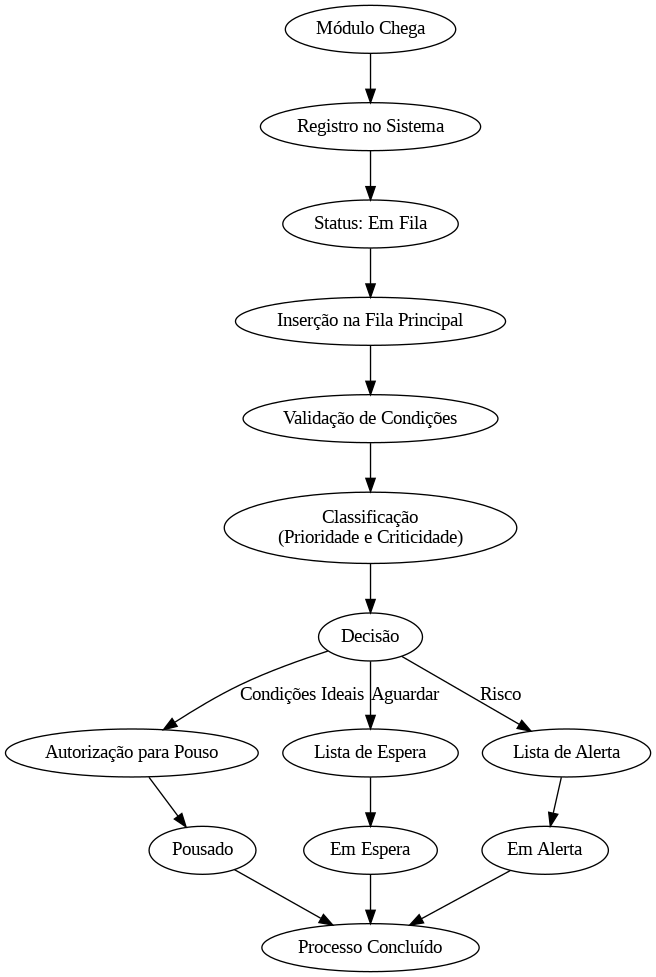
---

## 1.5 Considerações de Projeto

A escolha do uso de um DataFrame permite:

- Facilidade na aplicação de algoritmos de ordenação e busca
- Clareza na visualização dos dados
- Flexibilidade para simular diferentes cenários operacionais
- Integração direta com futuras análises e modelagens matemáticas

Essa abordagem mantém o sistema simples, mas suficientemente robusto para representar o funcionamento de um módulo de gerenciamento de pouso em um ambiente simulado.

# 2. Regras de Decisão com Portas Lógicas

## 2.1 Variáveis de Decisão

Para determinar a autorização de pouso dos módulos, foram definidas variáveis booleanas que representam o estado das principais condições operacionais:

| Variável | Tipo | Descrição |
|----------|------|-----------|
| combustivel_ok | boolean | Indica se o nível de combustível é suficiente para um pouso seguro |
| atmosfera_ok | boolean | Indica se as condições atmosféricas são favoráveis |
| area_disponivel | boolean | Indica se há área de pouso livre |
| sensores_ok | boolean | Indica se os sensores do módulo estão funcionando corretamente |
| alerta_combustivel | boolean | Indica se o módulo está em situação crítica de combustível |
| alta_prioridade | boolean | Indica se o módulo possui prioridade elevada |

---

## 2.2 Regras Gerais do Sistema

O sistema foi projetado com as seguintes diretrizes:

- Sensores e área de pouso são condições obrigatórias para qualquer decisão  
- Em condições normais, o sistema segue a ordem da fila (FIFO)  
- A prioridade só influencia decisões em situações de alerta  
- Módulos com combustível crítico podem ter prioridade emergencial  

---

## 2.3 Modelagem Lógica das Decisões

### 1. Condição Base (Obrigatória)

Nenhum módulo pode pousar sem atender às condições mínimas:

    condicao_base = sensores_ok AND area_disponivel

---

### 2. Pouso Normal (Fluxo padrão)

Quando não há situação de alerta, o sistema segue a fila, desde que todas as condições estejam adequadas:

    pouso_normal = condicao_base
                   AND combustivel_ok
                   AND atmosfera_ok
                   AND NOT alerta_combustivel

Interpretação:
- Tudo está funcionando corretamente  
- Não há situação crítica  
- O módulo pode pousar respeitando a ordem de chegada  

---

### 3. Pouso Prioritário (Situação de Alerta)

Em caso de combustível crítico, o módulo pode receber prioridade emergencial:

    pouso_prioritario = condicao_base
                        AND alerta_combustivel
                        AND alta_prioridade

Interpretação:
- O módulo está em risco  
- Possui prioridade elevada  
- Pode furar a fila  

---

### 4. Estado de Espera

O módulo deve aguardar quando as condições não são ideais, mas não há risco imediato:

    espera = condicao_base
             AND (NOT atmosfera_ok OR NOT combustivel_ok)
             AND NOT alerta_combustivel

Interpretação:
- O sistema está operacional  
- Algumas condições não são ideais  
- Não há urgência crítica  

---

### 5. Estado de Alerta

O módulo entra em alerta quando há risco operacional relevante:

    alerta = (NOT combustivel_ok) OR (NOT sensores_ok)

Interpretação:
- Combustível insuficiente  
- Falha nos sensores  
- Situação crítica que exige atenção imediata  

---

## 2.4 Representação com Portas Lógicas

### Estrutura Geral da Decisão

    condicao_base (sensores AND área)
                |
        -----------------------
        |                     |
    pouso_normal      pouso_prioritario    

---

### Exemplo de Porta Lógica (Pouso Normal)

    sensores_ok ----\
                     AND ----\
    area_disponivel -/        \
                              AND ----\
    combustivel_ok -----------/        \
                                       AND ---- resultado
    atmosfera_ok ---------------------/
                                       AND
    NOT alerta_combustivel -----------/

---

## 2.5 Considerações de Projeto

A modelagem por portas lógicas permite:

- Clareza na definição das regras de decisão  
- Facilidade de implementação em código (uso direto de operadores booleanos)  
- Maior confiabilidade na simulação do sistema  
- Possibilidade de expansão futura com novas condições  

Além disso, a separação entre fluxo normal e situações de alerta reflete práticas reais de sistemas críticos, nos quais eventos emergenciais possuem tratamento diferenciado.

# 3. Implementação do Protótipo em Python

## 3.1 Abordagem de Implementação

O protótipo do Módulo de Gerenciamento de Pouso e Estabilização de Base (MGPEB) foi desenvolvido em Python com o objetivo de simular o fluxo de decisão para autorização de pouso dos módulos.

Inicialmente, foi considerada a utilização de estruturas baseadas em DataFrame (Pandas), devido à sua praticidade para manipulação de dados tabulares. No entanto, como o objetivo da atividade inclui a aplicação explícita de algoritmos clássicos de busca e ordenação, optou-se por implementar essas operações manualmente, utilizando estruturas lineares nativas da linguagem (listas).

Essa decisão permite maior controle sobre a lógica aplicada e melhor aderência aos conceitos estudados.

---

## 3.2 Estruturas de Dados

Os módulos foram representados como dicionários dentro de uma lista, simulando a fila de pouso.

Cada módulo contém os seguintes atributos:

- tipo  
- prioridade  
- combustivel  
- massa  
- criticidade  
- horario_chegada  
- status  

A lista principal representa a fila de módulos aguardando decisão, enquanto o status indica o estado atual de cada módulo no sistema.

---

## 3.3 Algoritmos Utilizados

### Busca

Foi implementada uma busca linear para identificar módulos com características específicas, como:

- menor nível de combustível  
- maior prioridade  

Essa abordagem percorre sequencialmente a lista até encontrar o elemento desejado.

---

### Ordenação

Para reorganizar a fila em situações de alerta, foi utilizado o algoritmo **Bubble Sort**, ordenando os módulos com base na prioridade.

Essa ordenação só é aplicada em cenários críticos, mantendo o comportamento FIFO em condições normais.

---

## 3.4 Simulação do Sistema

O sistema percorre a fila de módulos e, para cada elemento:

1. Avalia as condições operacionais  
2. Aplica as regras lógicas definidas anteriormente  
3. Define o status do módulo como:
   - pousado  
   - espera  
   - alerta  

Os resultados são exibidos no console, permitindo observar o comportamento do sistema em diferentes cenários.

---

## 3.5 Código-Fonte

O código completo do protótipo pode ser acessado no repositório:

👉 [INSERIR LINK DO GITHUB AQUI]

# 4. Modelagem de Função Matemática Aplicada

## 4.1 Fenômeno Escolhido

Foi escolhido modelar o **consumo de combustível ao longo do tempo durante a descida do módulo**.

Esse fenômeno é fundamental para o sistema MGPEB, pois o nível de combustível influencia diretamente as decisões de pouso, especialmente em situações de alerta.

---

## 4.2 Modelo Matemático

O consumo de combustível foi representado por uma **função exponencial decrescente**, dada por:

C(t) = C₀ * e^(-k * t)

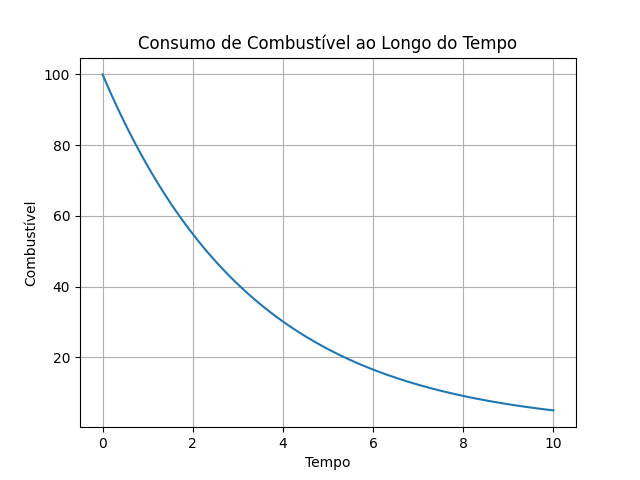

Onde:

- C(t): quantidade de combustível no tempo t  
- C₀: quantidade inicial de combustível  
- k: taxa de consumo  
- t: tempo  

---

## 4.3 Interpretação da Função

- À medida que o tempo aumenta, o combustível diminui de forma não linear  
- A queda é mais acentuada no início e vai suavizando com o tempo  
- Quanto maior o valor de k, mais rápido o combustível é consumido  

Esse comportamento representa bem uma situação real, onde o consumo é mais intenso durante fases críticas da descida.

---

## 4.4 Análise Qualitativa do Gráfico

O gráfico da função apresenta:

- Curva decrescente  
- Nunca atinge exatamente zero, mas se aproxima ao longo do tempo  
- Forte sensibilidade ao tempo em estágios iniciais  

Isso indica que decisões tardias podem ser críticas, pois o combustível pode atingir níveis perigosos rapidamente.

---

## 4.5 Aplicação no MGPEB

Essa modelagem auxilia diretamente nas decisões do sistema:

- Permite identificar quando um módulo entrará em estado de alerta  
- Justifica a priorização de módulos com baixo combustível  
- Auxilia na definição do momento ideal para autorização de pouso  
- Evita que módulos aguardem na fila até níveis críticos  

Dessa forma, a função matemática não apenas descreve um fenômeno físico, mas também orienta decisões estratégicas dentro do sistema.

# 5. Evolução da Computação e o Contexto do MGPEB

## 5.1 Dos Primeiros Computadores aos Sistemas Embarcados

A computação moderna começou com máquinas como o ENIAC (1945), EDVAC e UNIVAC I, que foram os primeiros computadores eletrônicos de propósito geral. Esses sistemas utilizavam válvulas, ocupavam salas inteiras, consumiam muita energia e apresentavam falhas frequentes.

Mesmo com essas limitações, eles estabeleceram conceitos fundamentais que usamos até hoje, como a arquitetura de von Neumann, o uso de memória para armazenar programas e a separação entre dados e instruções.

Com o avanço para transistores (anos 1950), circuitos integrados (anos 1960) e microprocessadores (a partir de 1970), os computadores ficaram menores, mais eficientes e confiáveis. Isso possibilitou o surgimento de sistemas embarcados, incluindo os utilizados em missões espaciais.

Um exemplo importante é o Apollo Guidance Computer (AGC), que operava com apenas 64 KB de memória e 2 MHz de clock. Mesmo assim, foi capaz de controlar missões extremamente complexas, mostrando que, com um bom projeto de software, é possível trabalhar com recursos limitados.

O sistema desenvolvido neste trabalho segue essa mesma linha: um sistema simples, mas estruturado para funcionar de forma confiável em um ambiente crítico.

---

## 5.2 Limitações de Hardware em Missões a Marte

Sistemas utilizados em Marte operam sob condições muito diferentes de um computador comum. Algumas das principais limitações são:

| Limitação | Características |
|----------|---------------|
| Processamento | CPUs como o RAD750 (~200 MHz), muito abaixo de dispositivos modernos |
| Memória | Aproximadamente 256 MB de RAM e 2 GB de armazenamento |
| Energia | Uso de RTG ou painéis solares (~110 W contínuos) |
| Radiação | Possibilidade de erros causados por partículas (SEUs) |
| Temperatura | Variação extrema (-125 °C a +20 °C) |
| Comunicação | Atraso de 4 a 24 minutos entre Terra e Marte |
| Manutenção | Não há possibilidade de reparo físico |

Essas limitações explicam por que o hardware espacial não acompanha o estado da arte comercial. Componentes mais antigos acabam sendo mais estáveis e resistentes à radiação.

---

## 5.3 Impacto no Desenvolvimento de Software

Essas restrições influenciam diretamente as escolhas de projeto.

### Estruturas de Dados

- Preferência por estruturas simples e previsíveis  
- Evita-se alocação dinâmica de memória sempre que possível  
- Uso de buffers controlados para evitar problemas de memória  

---

### Algoritmos

- Preferência por algoritmos com comportamento previsível  
- Baixo custo computacional é essencial  
- Uso de operações simples sempre que possível  

---

### Programação Defensiva

- Redundância em cálculos críticos  
- Uso de correção de erros (ECC)  
- Watchdog timers para reinício automático em falhas  
- Checkpoints para recuperação de estado  
- Testes extensivos antes da operação  

---

### Autonomia do Sistema

Devido ao atraso na comunicação com a Terra, o sistema precisa tomar decisões sozinho.

Isso exige:

- Lógica bem definida e previsível  
- Estados de segurança (safe mode)  
- Controle de execução em tempo real  
- Capacidade de reagir a falhas sem intervenção externa  

---

## 5.4 Conclusão

O sistema proposto neste trabalho reflete a evolução da computação ao longo das últimas décadas, aplicando conceitos clássicos em um contexto moderno e crítico.

Mais do que desempenho, sistemas embarcados em missões espaciais exigem confiabilidade. Isso reforça a ideia de que um bom projeto de software, aliado a escolhas simples e bem estruturadas, pode ser mais importante do que o uso de tecnologias mais avançadas.

Nesse sentido, o MGPEB segue princípios semelhantes aos utilizados em sistemas reais: decisões claras, estruturas simples e foco em robustez, garantindo funcionamento mesmo em condições adversas.

# 6. Princípios ESG na Base Aurora Siger

## 6.1 Perspectiva Geral

A construção da base Aurora Siger em Marte representa uma oportunidade única: começar do zero e evitar erros já cometidos na Terra, principalmente em relação ao uso de recursos e impacto ambiental.

Nesse contexto, a aplicação de princípios ESG não é apenas desejável, mas essencial para garantir que a colônia cresça de forma sustentável, organizada e responsável.

---

## 6.2 Critérios para Escolha da Área de Pouso

A definição das áreas de pouso deve considerar não apenas fatores técnicos, mas também o impacto a longo prazo no ambiente marciano.

Diferente do que ocorreu na Terra, onde muitas decisões priorizaram expansão rápida sem planejamento, em Marte o ideal é começar de forma estruturada:

- Definir zonas específicas para pouso, separadas de áreas de habitação e pesquisa  
- Evitar regiões com potencial científico relevante, como presença de gelo ou indícios de vida passada  
- Reduzir ao máximo a dispersão de poeira, que pode afetar equipamentos e contaminar outras áreas  
- Planejar a expansão da base desde o início, evitando ocupação desordenada  

A ideia é evitar um crescimento caótico e garantir que a base se desenvolva de forma sustentável desde o início.

---

## 6.3 Gestão de Recursos e Sustentabilidade

A limitação de recursos em Marte exige uma abordagem muito mais controlada do que na Terra.

Alguns princípios básicos:

- Uso eficiente de energia, priorizando fontes renováveis como energia solar  
- Controle rigoroso do consumo de recursos  
- Redução e reaproveitamento de resíduos sempre que possível  
- Planejamento do uso de recursos locais de forma responsável  

Esse tipo de gestão evita desperdícios e garante que a base consiga se manter no longo prazo, sem depender de reposição constante da Terra.

---

## 6.4 Governança e Tomada de Decisão

A governança da base deve ser simples, clara e baseada em regras bem definidas.

Para isso:

- As decisões devem seguir critérios objetivos (como prioridade, combustível e condições operacionais)  
- O sistema deve registrar as decisões tomadas, permitindo análise posterior  
- As regras devem ser conhecidas e compreensíveis por todos os envolvidos  

O MGPEB contribui diretamente nesse ponto, pois utiliza lógica definida para tomada de decisão, evitando arbitrariedade e garantindo consistência no gerenciamento dos pousos.

---

## 6.5 Integração com o MGPEB

Os princípios ESG estão diretamente ligados ao funcionamento do sistema desenvolvido.

- A organização dos pousos evita impacto desnecessário no ambiente  
- A priorização de módulos críticos contribui para a segurança da base  
- O uso de regras claras garante transparência nas decisões  

Isso mostra que o sistema não apenas resolve um problema técnico, mas também ajuda a estruturar uma operação mais responsável.

---

## 6.6 Conclusão

A base Aurora Siger não deve apenas replicar modelos já utilizados na Terra, mas sim aprender com seus erros.

Ao aplicar princípios ESG desde o início, é possível construir uma colônia mais organizada, sustentável e preparada para o longo prazo.

Nesse sentido, o MGPEB contribui não só para o gerenciamento de pousos, mas também para uma abordagem mais consciente da ocupação humana em Marte.